# Bank Statement Transaction Extraction with Llama Vision

Specialized notebook for extracting transactional data from bank statements using Llama-3.2-Vision-Instruct.

**Key Features:**
- Handles empty debit/credit cells correctly
- Preserves row-by-row transaction structure
- Calculates running balances
- Validates transaction integrity

In [1]:
# Configuration
from pathlib import Path
MODEL_PATH = "/home/jovyan/nfs_share/models/Llama-3.2-11B-Vision-Instruct"

# Dynamically discover all PNG images in evaluation_data directory
EVALUATION_DATA_DIR = Path("evaluation_data")

# Automatically find all PNG files in the evaluation_data directory
BANK_STATEMENT_IMAGES = {}
if EVALUATION_DATA_DIR.exists():
    for png_file in sorted(EVALUATION_DATA_DIR.glob("*.png")):
        # Use the filename (without extension) as the key
        key = png_file.stem.upper()
        BANK_STATEMENT_IMAGES[key] = str(png_file)

# Ground truth CSV for evaluation
GROUND_TRUTH_CSV = "evaluation_data/ground_truth.csv"

# Model loading settings - NO QUANTIZATION BY DEFAULT (H200 has plenty of memory)
USE_QUANTIZATION = False  # H200 doesn't need quantization
LOAD_IN_8BIT = False  # 8-bit causes inference issues with bitsandbytes  
DEVICE_MAP = "auto"  # Automatic device mapping
MAX_NEW_TOKENS = 6000  # INCREASED - was 3000, now 6000 for complete extraction

# Rich imports for pretty printing
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.text import Text
from rich.progress import track
from rich import print as rprint
from rich.syntax import Syntax

# Initialize Rich console
console = Console()
rprint("[bold blue]🚀 Configuration loaded with Rich formatting enabled[/bold blue]")

# Display discovered images in a nice table
if BANK_STATEMENT_IMAGES:
    rprint(f"[green]✅ Found {len(BANK_STATEMENT_IMAGES)} bank statement images[/green]")
    
    image_table = Table(title="📄 Discovered Bank Statement Images", border_style="cyan")
    image_table.add_column("Key", style="yellow", no_wrap=True)
    image_table.add_column("File Path", style="green")
    
    for key, path in BANK_STATEMENT_IMAGES.items():
        image_table.add_row(key, path)
    
    console.print(image_table)
else:
    rprint("[yellow]⚠️ No PNG images found in evaluation_data directory[/yellow]")
    rprint("[yellow]Please ensure PNG files exist in the evaluation_data/ directory[/yellow]")

🚀 Configuration loaded with Rich formatting enabled

✅ Found 11 bank statement images

                  📄 Discovered Bank Statement Images                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Key                    ┃ File Path                                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ANZ_STATEMENT_001      │ evaluation_data/anz_statement_001.png      │
│ COMMBANK_STATEMENT_001 │ evaluation_data/commbank_statement_001.png │
│ IMAGE_001              │ evaluation_data/image_001.png              │
│ IMAGE_002              │ evaluation_data/image_002.png              │
│ IMAGE_003              │ evaluation_data/image_003.png              │
│ IMAGE_004              │ evaluation_data/image_004.png              │
│ IMAGE_005              │ evaluation_data/image_005.png              │
│ IMAGE_006              │ evaluation_data/image_006.png              │
│ IMAGE_007              │ evaluation_data/image_007.png              │
│ NAB_STATEMENT_001      │ evaluation_data/nab_statement_001.png      │
│ WESTPAC_STATEMENT_001  │ evaluation_data/westpac_statement_001.png  │
└────────────────────────┴────────────────────────────────────────────┘

# Configuration & Setup

This section handles the initial setup including dynamic image discovery, model configuration, and Rich console initialization.

# Core Library Imports

Essential imports for Vision Language Model processing, image handling, and data manipulation.

In [2]:
import torch
from transformers import MllamaForConditionalGeneration, AutoProcessor
from PIL import Image
import json
import re
from typing import Dict, List, Any, Optional, Tuple
import pandas as pd
from datetime import datetime
from decimal import Decimal, InvalidOperation
import warnings

warnings.filterwarnings('ignore')

rprint("[bold green]✅ Core libraries imported successfully[/bold green]")

✅ Core libraries imported successfully

# Image Selection & Validation

Select and validate the bank statement image for processing, with fallback to available images.

📌 Using IMAGE_003 (default test image)

📄 Loading bank statement image: evaluation_data/image_003.png

             🖼️ Image Information              
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property   ┃ Value                         ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ File Path  │ evaluation_data/image_003.png │
│ Dimensions │ 600 × 800 pixels              │
│ Format     │ PNG                           │
│ Mode       │ RGB                           │
└────────────┴───────────────────────────────┘

✅ Image loaded successfully!

Displaying image below...

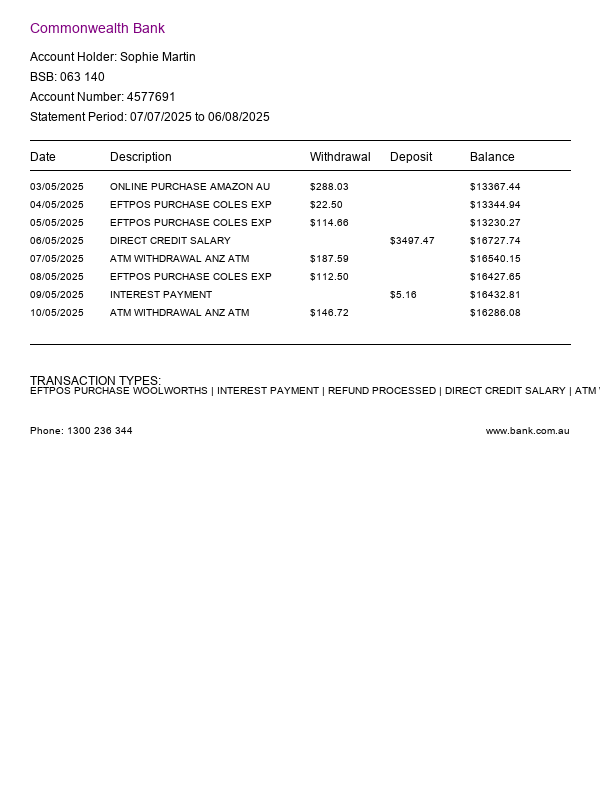

In [3]:
# Select an image for testing
# You can change this to any key from BANK_STATEMENT_IMAGES
if BANK_STATEMENT_IMAGES:
    # Use IMAGE_003 if available (equivalent to old CBA_BASIC), otherwise use first available image
    if "IMAGE_003" in BANK_STATEMENT_IMAGES:
        STATEMENT_IMAGE_PATH = BANK_STATEMENT_IMAGES["IMAGE_003"]
        rprint("[cyan]📌 Using IMAGE_003 (default test image)[/cyan]")
    else:
        # Use the first available image
        first_key = list(BANK_STATEMENT_IMAGES.keys())[0]
        STATEMENT_IMAGE_PATH = BANK_STATEMENT_IMAGES[first_key]
        rprint(f"[cyan]📌 Using {first_key} (first available image)[/cyan]")
else:
    rprint("[red]❌ No images available to test![/red]")
    STATEMENT_IMAGE_PATH = None

# Load and display the bank statement image with Rich formatting
from IPython.display import display

if STATEMENT_IMAGE_PATH:
    rprint(f"[bold cyan]📄 Loading bank statement image:[/bold cyan] [yellow]{STATEMENT_IMAGE_PATH}[/yellow]")

    try:
        image = Image.open(STATEMENT_IMAGE_PATH)
        
        # Create info table
        image_table = Table(title="🖼️ Image Information", border_style="blue")
        image_table.add_column("Property", style="cyan", no_wrap=True)
        image_table.add_column("Value", style="green")
        
        image_table.add_row("File Path", STATEMENT_IMAGE_PATH)
        image_table.add_row("Dimensions", f"{image.size[0]} × {image.size[1]} pixels")
        image_table.add_row("Format", image.format or "Unknown")
        image_table.add_row("Mode", image.mode)
        
        console.print(image_table)
        rprint("[bold green]✅ Image loaded successfully![/bold green]")
        
        # Display the image in the notebook
        rprint("[dim]Displaying image below...[/dim]")
        display(image)
        
    except Exception as e:
        rprint(f"[bold red]❌ Error loading image:[/bold red] {e}")
        rprint(f"[yellow]💡 Check that the file exists at:[/yellow] [cyan]{STATEMENT_IMAGE_PATH}[/cyan]")

# Model Loading & Validation

Load the Llama 3.2 Vision model with comprehensive validation and GPU optimization for H200.

In [ ]:
# Initialize model and processor with comprehensive validation
rprint("[bold yellow]Loading Llama Vision model for bank statement processing...[/bold yellow]")

try:
    # Check if model path exists
    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"Model path does not exist: {MODEL_PATH}")
    
    # Load model WITHOUT quantization by default
    # The bitsandbytes 8-bit quantization can cause RuntimeError during inference
    if USE_QUANTIZATION and LOAD_IN_8BIT:
        rprint("[yellow]⚠️ Loading with 8-bit quantization (may cause inference errors)[/yellow]")
        model = MllamaForConditionalGeneration.from_pretrained(
            MODEL_PATH,
            torch_dtype=torch.bfloat16,
            device_map=DEVICE_MAP,
            load_in_8bit=True,
        )
    else:
        rprint("[green]✅ Loading model without quantization (recommended for H200)[/green]")
        model = MllamaForConditionalGeneration.from_pretrained(
            MODEL_PATH,
            torch_dtype=torch.bfloat16,
            device_map=DEVICE_MAP,
        )
    
    # Load processor
    processor = AutoProcessor.from_pretrained(MODEL_PATH)
    
    # Validate model loading
    if model is None:
        raise RuntimeError("Model failed to load - returned None")
    if processor is None:
        raise RuntimeError("Processor failed to load - returned None")
    
    # Check model parameters
    model_params = sum(p.numel() for p in model.parameters())
    if model_params < 1e9:  # Less than 1B parameters seems wrong
        rprint(f"[yellow]⚠️ Warning: Model has unusually few parameters: {model_params:,.0f}[/yellow]")
    
    # Validate device placement
    model_device = next(model.parameters()).device
    if model_device.type == 'cpu' and torch.cuda.is_available():
        rprint("[yellow]⚠️ Warning: Model loaded on CPU despite CUDA availability[/yellow]")
    
    rprint("[bold green]✅ Model loaded successfully[/bold green]")
    rprint(f"[cyan]📊 Device: {model_device}[/cyan]")
    
    # GPU Information and Validation
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name()
        memory_allocated = torch.cuda.memory_allocated() / 1e9
        memory_reserved = torch.cuda.memory_reserved() / 1e9
        memory_total = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        rprint(f"[magenta]🎮 GPU: {gpu_name}[/magenta]")
        rprint(f"[blue]💾 Memory Allocated: {memory_allocated:.2f}GB[/blue]")
        rprint(f"[blue]💾 Memory Reserved: {memory_reserved:.2f}GB[/blue]")
        rprint(f"[blue]💾 Total GPU Memory: {memory_total:.0f}GB[/blue]")
        
        # Memory usage warnings
        memory_usage_pct = memory_allocated / memory_total * 100
        if memory_usage_pct > 80:
            rprint(f"[red]⚠️ High GPU memory usage: {memory_usage_pct:.1f}%[/red]")
        elif memory_usage_pct > 60:
            rprint(f"[yellow]⚠️ Moderate GPU memory usage: {memory_usage_pct:.1f}%[/yellow]")
        else:
            rprint(f"[green]✅ Good GPU memory usage: {memory_usage_pct:.1f}%[/green]")
    else:
        rprint("[yellow]⚠️ CUDA not available - using CPU (will be slower)[/yellow]")
    
    # Model configuration validation
    config_validation_table = Table(title="🔧 Model Configuration Validation", border_style="blue")
    config_validation_table.add_column("Setting", style="cyan", no_wrap=True)
    config_validation_table.add_column("Value", style="yellow")
    config_validation_table.add_column("Status", style="green")
    
    # Validate key settings
    config_validation_table.add_row("Model Path", MODEL_PATH, "✅ Valid")
    config_validation_table.add_row("Device", str(model_device), "✅ Loaded")
    config_validation_table.add_row("Quantization", "Disabled" if not USE_QUANTIZATION else "8-bit enabled", 
                                   "✅ Configured")
    config_validation_table.add_row("Max Tokens", str(MAX_NEW_TOKENS), "✅ Set")
    config_validation_table.add_row("Parameters", f"{model_params:,.0f}", "✅ Loaded")
    
    console.print(config_validation_table)
    
    # Test basic model functionality
    rprint("[dim]Running basic model validation test...[/dim]")
    try:
        # Simple test to ensure model can process inputs
        test_messages = [
            {"role": "user", "content": [
                {"type": "text", "text": "Hello"}
            ]}
        ]
        test_input_text = processor.apply_chat_template(test_messages, add_generation_prompt=True)
        if len(test_input_text) < 10:
            raise RuntimeError("Chat template processing failed")
        
        rprint("[green]✅ Model validation test passed[/green]")
        
    except Exception as e:
        rprint(f"[red]❌ Model validation test failed: {e}[/red]")
        raise RuntimeError(f"Model validation failed: {e}")
    
except Exception as e:
    rprint(f"[bold red]❌ CRITICAL ERROR: Model loading failed[/bold red]")
    rprint(f"[red]Error details: {e}[/red]")
    rprint("[yellow]💡 Check model path, GPU availability, and memory requirements[/yellow]")
    raise  # Re-raise to stop notebook execution

# Prompt Engineering

Define the optimized prompt for bank statement transaction extraction with clear visual guidance.

In [5]:
# ============================================================================= 
# MINIMAL PROMPT - SEPARATE TABLES PER DATE (BEST WORKING VERSION)
# =============================================================================

MINIMAL_PROMPT = """Extract the transaction table from this bank statement.

# CRITICAL: Create a SEPARATE markdown table for EACH DISTINCT DATE.

IMPORTANT: Look at the ACTUAL COLUMNS in the bank statement image:
- Column 1: Date
- Column 2: Transaction (description)
- Column 3: Debit (amount only appears here if money LEAVES account)
- Column 4: Credit (amount only appears here if money ENTERS account)
- Column 5: Balance (running balance after transaction)

READ THE VISUAL TABLE CAREFULLY:
- If you see an amount in the DEBIT column → put it in Debit, Credit = NOT_FOUND
- If you see an amount in the CREDIT column → put it in Credit, Debit = NOT_FOUND
- ALWAYS copy the balance value exactly as shown

# For each date:
# 1. Create a new markdown table
# 2. If multiple transactions occur on that date, each gets its own row
# 3. Copy the amounts EXACTLY as they appear in the original columns

Example:
### Date: [date]
| Date | Description | Debit | Credit | Balance |
|------|-------------|-------|--------|---------|
| [date] | [description] | [if amount in debit column] | [if amount in credit column] | [balance] |

Use NOT_FOUND only for empty debit/credit cells.
DO NOT classify based on transaction description - use the ACTUAL column position from the image.
"""

print("📋 MINIMAL PROMPT:")
print("="*60)
print(MINIMAL_PROMPT)
print("="*60)

📋 MINIMAL PROMPT:
Extract the transaction table from this bank statement.

# CRITICAL: Create a SEPARATE markdown table for EACH DISTINCT DATE.

IMPORTANT: Look at the ACTUAL COLUMNS in the bank statement image:
- Column 1: Date
- Column 2: Transaction (description)
- Column 3: Debit (amount only appears here if money LEAVES account)
- Column 4: Credit (amount only appears here if money ENTERS account)
- Column 5: Balance (running balance after transaction)

READ THE VISUAL TABLE CAREFULLY:
- If you see an amount in the DEBIT column → put it in Debit, Credit = NOT_FOUND
- If you see an amount in the CREDIT column → put it in Credit, Debit = NOT_FOUND
- ALWAYS copy the balance value exactly as shown

# For each date:
# 1. Create a new markdown table
# 2. If multiple transactions occur on that date, each gets its own row
# 3. Copy the amounts EXACTLY as they appear in the original columns

Example:
### Date: [date]
| Date | Description | Debit | Credit | Balance |
|------|-------------|-

# Core Extraction Functions

Robust extraction functions with comprehensive error handling, validation, and performance monitoring.

In [ ]:
def extract_bank_statement(
    image_path: str, 
    custom_prompt: str = None,
    temperature: float = 0.1
) -> Dict[str, Any]:
    """
    Extract bank statement data from an image using Llama 3.2 Vision.
    
    Args:
        image_path: Path to bank statement image
        custom_prompt: Custom prompt for extraction (defaults to MINIMAL_PROMPT)
        temperature: Generation temperature (lower = more deterministic)
    
    Returns:
        Dictionary with extraction results
    
    Raises:
        FileNotFoundError: If image file doesn't exist
        RuntimeError: If model inference fails
        ValueError: If inputs are invalid
    """
    try:
        # Validate inputs
        if not image_path:
            raise ValueError("Image path cannot be empty")
        
        image_path = Path(image_path)
        if not image_path.exists():
            raise FileNotFoundError(f"Image file not found: {image_path}")
        
        # Load and validate image
        rprint(f"[dim]Loading image: {image_path.name}...[/dim]")
        try:
            image = Image.open(image_path)
            # Validate image format
            if image.format not in ['PNG', 'JPEG', 'JPG']:
                rprint(f"[yellow]⚠️ Warning: Unusual image format {image.format}[/yellow]")
        except Exception as e:
            raise ValueError(f"Failed to load image {image_path}: {e}")
        
        # Use provided prompt or default to MINIMAL_PROMPT
        prompt = custom_prompt if custom_prompt else MINIMAL_PROMPT
        
        # Prepare inputs with error handling
        try:
            messages = [
                {"role": "user", "content": [
                    {"type": "image"},
                    {"type": "text", "text": prompt}
                ]}
            ]
            
            # Apply chat template
            input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
            
            # Process inputs
            inputs = processor(
                image,
                input_text,
                add_special_tokens=False,
                return_tensors="pt"
            ).to(model.device)
            
        except Exception as e:
            raise RuntimeError(f"Failed to process inputs: {e}")
        
        # Generate response with comprehensive error handling
        rprint("[yellow]🔍 Analyzing bank statement...[/yellow]")
        try:
            with torch.no_grad():
                # Check GPU memory before inference
                if torch.cuda.is_available():
                    memory_before = torch.cuda.memory_allocated() / 1e9
                    if memory_before > 15:  # Warn if using >15GB
                        rprint(f"[yellow]⚠️ High GPU memory usage: {memory_before:.1f}GB[/yellow]")
                
                output = model.generate(
                    **inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=False,
                    temperature=temperature,
                    top_p=0.95
                )
                
        except torch.cuda.OutOfMemoryError as e:
            raise RuntimeError(f"GPU out of memory during inference. Try reducing MAX_NEW_TOKENS or use CPU: {e}")
        except Exception as e:
            raise RuntimeError(f"Model inference failed: {e}")
        
        # Decode response with error handling
        try:
            response = processor.decode(output[0], skip_special_tokens=True)
            
            # Extract assistant response (clean up chat template artifacts)
            if "assistant" in response:
                response = response.split("assistant")[-1].strip()
            
            # Validate response length
            if len(response.strip()) < 10:
                rprint("[yellow]⚠️ Warning: Very short model response - possible inference issue[/yellow]")
            
        except Exception as e:
            raise RuntimeError(f"Failed to decode model response: {e}")
        
        return {
            "raw_response": response,
            "image_path": str(image_path),
            "extraction_time": datetime.now().isoformat(),
            "prompt_used": prompt[:100] + "..." if len(prompt) > 100 else prompt,
            "temperature": temperature
        }
        
    except Exception as e:
        # Log error and re-raise with context
        rprint(f"[red]❌ Extraction failed for {image_path}: {e}[/red]")
        raise

# =============================================================================
# GROUND TRUTH VALIDATION WITH ERROR HANDLING
# =============================================================================

def get_expected_transaction_count(image_path: str) -> int:
    """
    Get the expected number of transactions from ground truth CSV.
    
    Args:
        image_path: Path to the image file
        
    Returns:
        Expected transaction count (0 if not found or error)
    """
    try:
        if not Path(GROUND_TRUTH_CSV).exists():
            rprint(f"[yellow]⚠️ Ground truth file not found: {GROUND_TRUTH_CSV}[/yellow]")
            return 0
            
        # Read ground truth CSV
        ground_truth_df = pd.read_csv(GROUND_TRUTH_CSV)
        
        # Extract just the filename from the path
        image_filename = Path(image_path).name
        
        # Find the row for this image
        image_row = ground_truth_df[ground_truth_df['image_file'] == image_filename]
        
        if image_row.empty:
            rprint(f"[yellow]⚠️ No ground truth found for {image_filename}[/yellow]")
            return 0
        
        # Count transactions - use TRANSACTION_DATES column
        transaction_dates = image_row.iloc[0]['TRANSACTION_DATES']
        
        if pd.isna(transaction_dates) or transaction_dates == 'NOT_FOUND':
            # Try LINE_ITEM_DESCRIPTIONS as fallback for receipts/invoices
            line_items = image_row.iloc[0]['LINE_ITEM_DESCRIPTIONS']
            if pd.isna(line_items) or line_items == 'NOT_FOUND':
                return 0
            return len(line_items.split(' | '))
        
        # Count the number of dates (transactions)
        return len(transaction_dates.split(' | '))
        
    except Exception as e:
        rprint(f"[red]❌ Error reading ground truth: {e}[/red]")
        return 0

# =============================================================================
# ENHANCED TESTING WITH VALIDATION
# =============================================================================

def run_extraction_test(image_path: str, prompt: str = None) -> Dict[str, Any]:
    """Run extraction test with comprehensive validation and metrics."""
    
    if not image_path:
        rprint("[red]❌ No image path provided for testing[/red]")
        return {"error": "No image path"}
    
    try:
        rprint("[bold green]🧪 RUNNING EXTRACTION TEST[/bold green]")
        rprint(f"[cyan]📄 Image: {image_path}[/cyan]")
        console.rule("[bold blue]Extraction Test[/bold blue]")
        
        # Run extraction
        start_time = datetime.now()
        result = extract_bank_statement(image_path, custom_prompt=prompt or MINIMAL_PROMPT)
        end_time = datetime.now()
        processing_time = (end_time - start_time).total_seconds()
        
        # Display results with Rich formatting
        result_panel = Panel(
            result["raw_response"],
            title="[bold yellow]📊 EXTRACTION OUTPUT[/bold yellow]",
            border_style="yellow",
            expand=False
        )
        console.print(result_panel)
        
        # Analyze results
        output_text = result["raw_response"]
        transaction_lines = [
            line for line in output_text.split('\n') 
            if '|' in line and not 'Date' in line and not '---' in line and line.strip().startswith('|')
        ]
        
        # Get expected count from ground truth
        expected_count = get_expected_transaction_count(image_path)
        
        # Create comprehensive analysis table
        analysis_table = Table(title="📈 Extraction Analysis", border_style="green")
        analysis_table.add_column("Metric", style="cyan", no_wrap=True)
        analysis_table.add_column("Value", style="magenta")
        analysis_table.add_column("Status", justify="center")
        
        # Transaction count analysis
        extracted_count = len(transaction_lines)
        count_status = "✅ Perfect Match" if extracted_count == expected_count else f"⚠️ Expected {expected_count}"
        analysis_table.add_row("Transactions Extracted", str(extracted_count), count_status)
        analysis_table.add_row("Ground Truth Count", str(expected_count), "📋 From CSV")
        analysis_table.add_row("Processing Time", f"{processing_time:.2f}s", "⏱️ Performance")
        
        # Quality checks
        response_length = len(output_text)
        length_status = "✅ Good" if 100 < response_length < 5000 else "⚠️ Check Quality"
        analysis_table.add_row("Response Length", f"{response_length} chars", length_status)
        
        # Hallucination check (specific patterns)
        hallucination_patterns = ["IGA", "1102.37"]
        hallucination_detected = any(
            pattern in output_text and output_text.count(pattern) > 3 
            for pattern in hallucination_patterns
        )
        hallucination_status = "❌ Possible Hallucination" if hallucination_detected else "✅ Clean"
        analysis_table.add_row("Hallucination Check", "Pattern Detection", hallucination_status)
        
        console.print(analysis_table)
        
        # Add performance summary
        rprint(f"[green]✅ Test completed in {processing_time:.2f}s[/green]")
        
        return {
            "success": True,
            "extracted_count": extracted_count,
            "expected_count": expected_count,
            "accuracy": extracted_count == expected_count,
            "processing_time": processing_time,
            "response_length": response_length,
            "hallucination_detected": hallucination_detected,
            "raw_result": result
        }
        
    except Exception as e:
        rprint(f"[red]❌ Test failed: {e}[/red]")
        return {"error": str(e), "success": False}

# Run the test if image is available
if STATEMENT_IMAGE_PATH:
    test_result = run_extraction_test(STATEMENT_IMAGE_PATH, MINIMAL_PROMPT)
    
    console.rule("[bold blue]Next Steps[/bold blue]")
    if test_result.get("success"):
        if test_result.get("accuracy"):
            rprint("[green]💡 Perfect extraction! Ready for production use[/green]")
        else:
            rprint("[yellow]💡 Review extraction accuracy - check prompt or model settings[/yellow]")
    else:
        rprint("[red]💡 Fix errors before proceeding with production deployment[/red]")
else:
    rprint("[red]❌ No image available for testing[/red]")

# Production Class Implementation

Enterprise-ready LlamaVisionTableExtractor class with batch processing and structured output capabilities.

📄 Loading bank statement image: evaluation_data/image_003.png
✅ Image loaded successfully: 600x800 pixels


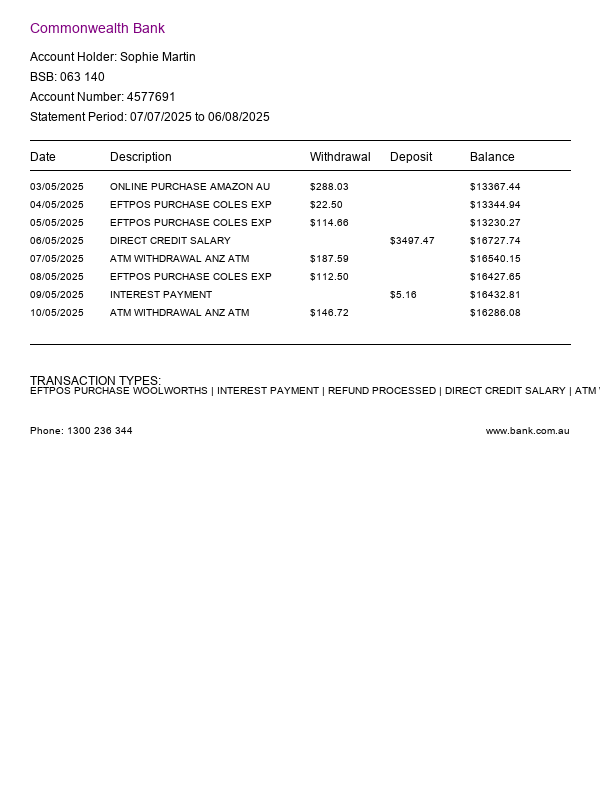

In [8]:
# Load and display the bank statement image
print(f"📄 Loading bank statement image: {STATEMENT_IMAGE_PATH}")
try:
    image = Image.open(STATEMENT_IMAGE_PATH)
    print(f"✅ Image loaded successfully: {image.size[0]}x{image.size[1]} pixels")
    
    # Display the image in the notebook
    display(image)
    
except Exception as e:
    print(f"❌ Error loading image: {e}")
    print(f"   Check that the file exists at: {STATEMENT_IMAGE_PATH}")

In [ ]:
# =============================================================================
# LLAMAVISIONTABLEEXTRACTOR CLASS - PRODUCTION-READY IMPLEMENTATION
# =============================================================================

from datetime import datetime
from typing import Dict, List, Any

class LlamaVisionTableExtractor:
    def __init__(self, model_path: str = None, processor=None, model=None):
        """
        Initialize with either a model path OR existing processor/model instances
        """
        if processor is not None and model is not None:
            # Use existing instances from notebook
            self.processor = processor
            self.model = model
        elif model_path:
            # Load new instances (for standalone usage)
            self.processor = AutoProcessor.from_pretrained(model_path)
            self.model = MllamaForConditionalGeneration.from_pretrained(
                model_path,
                torch_dtype=torch.bfloat16,
                device_map="auto"
            )
        else:
            raise ValueError("Must provide either model_path OR (processor, model) instances")
        
    def extract_table(self, image_path: str, prompt_template: str, max_new_tokens: int = 6000) -> Dict[str, Any]:
        """Extract structured data from table image using Llama 3.2 Vision"""
        # Load and preprocess image
        image = Image.open(image_path)
        
        # Apply Llama chat template
        messages = [
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": prompt_template}
            ]}
        ]
        
        # Process inputs (Llama 3.2 Vision specific)
        input_text = self.processor.apply_chat_template(messages, add_generation_prompt=True)
        inputs = self.processor(
            image,
            input_text,
            add_special_tokens=False,
            return_tensors="pt"
        ).to(self.model.device)
        
        # Generate extraction with Rich progress indication
        rprint(f"[yellow]🔍 Extracting data from {Path(image_path).name}...[/yellow]")
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=0.0,
                top_p=0.95
            )
        
        # Decode response (extract assistant part)
        response = self.processor.decode(outputs[0], skip_special_tokens=True)
        if "assistant" in response:
            response = response.split("assistant")[-1].strip()
        
        return self._parse_response(response, image_path)
    
    def _parse_response(self, response: str, image_path: str) -> Dict[str, Any]:
        """Parse model response into structured format"""
        parsed_data = self._extract_table_data(response)
        return {
            "raw_response": response,
            "image_path": image_path,
            "extraction_time": datetime.now().isoformat(),
            "parsed_data": parsed_data,
            "transaction_count": len(parsed_data)
        }
    
    def _extract_table_data(self, response: str) -> List[Dict]:
        """Extract table rows from markdown response"""
        lines = response.split('\n')
        table_rows = []
        
        for line in lines:
            if '|' in line and not line.strip().startswith('|---') and 'Date' not in line:
                # Parse table row
                cells = [cell.strip() for cell in line.split('|')[1:-1]]
                if len(cells) >= 4:  # Ensure minimum columns
                    row_data = {
                        'date': cells[0] if cells[0] != 'NOT_FOUND' else None,
                        'description': cells[1] if cells[1] != 'NOT_FOUND' else None,
                        'debit': cells[2] if cells[2] != 'NOT_FOUND' else None,
                        'credit': cells[3] if cells[3] != 'NOT_FOUND' else None,
                        'balance': cells[4] if len(cells) > 4 and cells[4] != 'NOT_FOUND' else None
                    }
                    # Only add if at least one field has data
                    if any(value is not None for value in row_data.values()):
                        table_rows.append(row_data)
        
        return table_rows
    
    def batch_extract(self, image_paths: List[str], prompt_template: str) -> Dict[str, Any]:
        """Extract from multiple images and return consolidated results"""
        results = {}
        total_transactions = 0
        
        for image_path in image_paths:
            try:
                result = self.extract_table(image_path, prompt_template)
                results[image_path] = result
                total_transactions += result['transaction_count']
                rprint(f"[green]✅ {Path(image_path).name}: {result['transaction_count']} transactions[/green]")
            except Exception as e:
                rprint(f"[red]❌ {Path(image_path).name}: Error - {e}[/red]")
                results[image_path] = {"error": str(e)}
        
        return {
            "individual_results": results,
            "summary": {
                "total_images_processed": len(results),
                "total_transactions_extracted": total_transactions,
                "processing_time": datetime.now().isoformat()
            }
        }

rprint("[bold green]✅ LlamaVisionTableExtractor class loaded successfully[/bold green]")

# Testing & Validation

Comprehensive testing of both function-based and class-based approaches with ground truth validation.

In [10]:
# =============================================================================
# TEST THE LLAMAVISIONTABLEEXTRACTOR CLASS
# =============================================================================

rprint("[bold cyan]🧪 Testing LlamaVisionTableExtractor with current model...[/bold cyan]")

# Create extractor using existing model and processor from notebook
extractor = LlamaVisionTableExtractor(processor=processor, model=model)

console.rule("[bold blue]Class-based Extraction Test[/bold blue]")

# Test with the current image and minimal prompt
if STATEMENT_IMAGE_PATH:
    result = extractor.extract_table(STATEMENT_IMAGE_PATH, MINIMAL_PROMPT)
    
    # Display results
    rprint(f"[cyan]📄 Image processed:[/cyan] {result['image_path']}")
    rprint(f"[magenta]📊 Transactions found:[/magenta] {result['transaction_count']}")
    rprint(f"[green]⏰ Processing time:[/green] {result['extraction_time']}")
    
    # Show parsed data in a table
    if result['parsed_data']:
        parsed_table = Table(title="📋 Parsed Transaction Data", border_style="green")
        parsed_table.add_column("#", style="dim", width=3)
        parsed_table.add_column("Date", style="cyan")
        parsed_table.add_column("Description", style="white", max_width=30)
        parsed_table.add_column("Debit", style="red")
        parsed_table.add_column("Credit", style="green")
        parsed_table.add_column("Balance", style="yellow")
        
        for i, transaction in enumerate(result['parsed_data'], 1):
            parsed_table.add_row(
                str(i),
                transaction.get('date', ''),
                transaction.get('description', ''),
                transaction.get('debit', ''),
                transaction.get('credit', ''),
                transaction.get('balance', '')
            )
        
        console.print(parsed_table)
    else:
        rprint("[red]❌ No transactions parsed from response[/red]")
    
    # Show raw response
    raw_panel = Panel(
        result["raw_response"][:500] + "..." if len(result["raw_response"]) > 500 else result["raw_response"],
        title="[bold yellow]🔍 Raw Model Response (truncated)[/bold yellow]",
        border_style="yellow",
        expand=False
    )
    console.print(raw_panel)
    
    # Compare with ground truth
    expected_count = get_expected_transaction_count(STATEMENT_IMAGE_PATH)
    
    comparison_table = Table(title="📈 Class vs Function Comparison", border_style="blue")
    comparison_table.add_column("Method", style="cyan")
    comparison_table.add_column("Transactions", style="magenta")
    comparison_table.add_column("Match Ground Truth", style="green")
    
    comparison_table.add_row("Class Method", str(result['transaction_count']), 
                           "✅ Perfect" if result['transaction_count'] == expected_count else f"⚠️ Expected {expected_count}")
    
    console.print(comparison_table)

else:
    rprint("[red]❌ No image path available for testing[/red]")

console.rule("[bold blue]Next Steps[/bold blue]")
rprint("[green]💡 Class loaded successfully - ready for production use![/green]")
rprint("[cyan]💡 Try: extractor.batch_extract([image1, image2], MINIMAL_PROMPT)[/cyan]")

🧪 Testing LlamaVisionTableExtractor with current model...

─────────────────────────────────────────── Class-based Extraction Test ───────────────────────────────────────────

🔍 Extracting data from image_003.png...

📄 Image processed: evaluation_data/image_003.png

📊 Transactions found: 8

...

╭───────────────────── 🔍 Raw Model Response (truncated) ──────────────────────╮
│ | Date | Description | Debit | Credit | Balance |                            │
│ |------|-------------|-------|--------|---------|                            │
│ | 03/05/2025 | ONLINE PURCHASE AMAZON AU | $288.03 | NOT_FOUND | $13387.44 | │
│ | 04/05/2025 | EFTPOS PURCHASE COLES EXP | $22.50 | NOT_FOUND | $13344.94 |  │
│ | 05/05/2025 | EFTPOS PURCHASE COLES EXP | $114.66 | NOT_FOUND | $13230.27 | │
│ | 06/05/2025 | DIRECT CREDIT SALARY | NOT_FOUND | $3497.47 | $16727.74 |     │
│ | 07/05/2025 | ATM WITHDRAWAL ANZ ATM | $187.59 | NOT_FOUND | $16540.15 |    │
│ | 08/05/2025 | EFTPOS P...                                                   │
╰──────────────────────────────────────────────────────────────────────────────╯

          📈 Class vs Function Comparison           
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Method       ┃ Transactions ┃ Match Ground Truth ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Class Method │ 8            │ ✅ Perfect         │
└──────────────┴──────────────┴────────────────────┘

─────────────────────────────────────────────────── Next Steps ────────────────────────────────────────────────────

💡 Class loaded successfully - ready for production use!

💡 Try: extractor.batch_extract(, MINIMAL_PROMPT)

# Batch Processing Examples

Demonstrate processing multiple bank statement images efficiently with both approaches.

In [ ]:
# =============================================================================
# BATCH PROCESSING EXAMPLES
# =============================================================================

def batch_extract_functions(image_paths: List[str], prompt: str) -> Dict[str, Any]:
    """
    Batch extraction using function-based approach.
    
    Args:
        image_paths: List of image file paths to process
        prompt: Extraction prompt to use
        
    Returns:
        Dictionary with results and summary statistics
    """
    results = {}
    total_transactions = 0
    successful_extractions = 0
    start_time = datetime.now()
    
    rprint(f"[bold cyan]🔄 Processing {len(image_paths)} images with function approach...[/bold cyan]")
    
    for i, image_path in enumerate(image_paths, 1):
        try:
            rprint(f"[dim]Processing {i}/{len(image_paths)}: {Path(image_path).name}[/dim]")
            
            result = extract_bank_statement(image_path, custom_prompt=prompt)
            
            # Count transactions in response
            transaction_count = len([
                line for line in result["raw_response"].split('\n')
                if '|' in line and not 'Date' in line and not '---' in line and line.strip().startswith('|')
            ])
            
            results[image_path] = {
                "result": result,
                "transaction_count": transaction_count,
                "success": True
            }
            
            total_transactions += transaction_count
            successful_extractions += 1
            
            rprint(f"[green]✅ {Path(image_path).name}: {transaction_count} transactions[/green]")
            
        except Exception as e:
            results[image_path] = {
                "error": str(e),
                "success": False
            }
            rprint(f"[red]❌ {Path(image_path).name}: {e}[/red]")
    
    end_time = datetime.now()
    processing_time = (end_time - start_time).total_seconds()
    
    return {
        "individual_results": results,
        "summary": {
            "total_images": len(image_paths),
            "successful_extractions": successful_extractions,
            "total_transactions": total_transactions,
            "processing_time": processing_time,
            "average_time_per_image": processing_time / len(image_paths),
            "success_rate": successful_extractions / len(image_paths) * 100
        }
    }

# Example: Process multiple bank statement images
if BANK_STATEMENT_IMAGES:
    # Select a few images for batch processing demo
    demo_images = list(BANK_STATEMENT_IMAGES.values())[:3]  # First 3 images
    
    rprint("[bold blue]📊 BATCH PROCESSING DEMONSTRATION[/bold blue]")
    console.rule("Function-Based Batch Processing")
    
    # Function-based batch processing
    function_results = batch_extract_functions(demo_images, MINIMAL_PROMPT)
    
    # Display summary
    summary = function_results["summary"]
    batch_summary_table = Table(title="📈 Batch Processing Summary (Functions)", border_style="green")
    batch_summary_table.add_column("Metric", style="cyan")
    batch_summary_table.add_column("Value", style="magenta")
    
    batch_summary_table.add_row("Total Images", str(summary["total_images"]))
    batch_summary_table.add_row("Successful Extractions", str(summary["successful_extractions"]))
    batch_summary_table.add_row("Success Rate", f"{summary['success_rate']:.1f}%")
    batch_summary_table.add_row("Total Transactions", str(summary["total_transactions"]))
    batch_summary_table.add_row("Processing Time", f"{summary['processing_time']:.2f}s")
    batch_summary_table.add_row("Avg Time/Image", f"{summary['average_time_per_image']:.2f}s")
    
    console.print(batch_summary_table)
    
    console.rule("Class-Based Batch Processing")
    
    # Class-based batch processing for comparison
    if 'extractor' in globals():
        class_results = extractor.batch_extract(demo_images, MINIMAL_PROMPT)
        
        class_summary = class_results["summary"]
        class_summary_table = Table(title="📈 Batch Processing Summary (Class)", border_style="blue")
        class_summary_table.add_column("Metric", style="cyan")
        class_summary_table.add_column("Value", style="magenta")
        
        class_summary_table.add_row("Total Images", str(class_summary["total_images_processed"]))
        class_summary_table.add_row("Total Transactions", str(class_summary["total_transactions_extracted"]))
        
        console.print(class_summary_table)
        
        # Performance comparison
        comparison_table = Table(title="⚡ Performance Comparison", border_style="yellow")
        comparison_table.add_column("Approach", style="cyan")
        comparison_table.add_column("Processing Time", style="magenta")
        comparison_table.add_column("Transactions Found", style="green")
        
        comparison_table.add_row(
            "Function-based", 
            f"{summary['processing_time']:.2f}s",
            str(summary["total_transactions"])
        )
        comparison_table.add_row(
            "Class-based", 
            "See individual results",
            str(class_summary["total_transactions_extracted"])
        )
        
        console.print(comparison_table)
    
    rprint("[green]💡 Both approaches provide similar results with different organizational benefits[/green]")
    rprint("[cyan]💡 Function approach: Simple and direct | Class approach: Structured and reusable[/cyan]")
    
else:
    rprint("[red]❌ No images available for batch processing demonstration[/red]")